<a href="https://colab.research.google.com/github/rithwikkolluri-coder/ML-PROJECTS-/blob/main/ML_PROJECT(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# BLOCK 1: LOAD DATASET
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

DATA_PATH = "/content/renewable_energy_dataset.csv"

# Fallback path for local execution
if not os.path.exists(DATA_PATH):
    DATA_PATH = "/mnt/data/renewable_energy_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully!")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

✅ Dataset loaded successfully!
Rows    : 263040
Columns : 26


,timestamp,site_id,energy_source,climate_zone,plant_capacity_mw,panel_efficiency,turbine_hub_height_m,hour,day,month,year,day_of_week,day_of_year,is_weekend,hour_sin,hour_cos,month_sin,month_cos,temperature_c,humidity_pct,cloud_cover_pct,wind_speed_mps,precipitation_mm,pressure_hpa,solar_irradiance_wm2,energy_output_kwh
0,01-01-2022 00:00,SOLAR_01_Rajasthan,Solar,Desert,50,0.204,NaN,0,1,1,2022,5,1,1,0.000000,1.000000,0.5,0.866025,24.75,82.0,1.4,2.45,0.0,1012.2,0.0,0.14
1,01-01-2022 01:00,SOLAR_01_Rajasthan,Solar,Desert,50,0.204,NaN,1,1,1,2022,5,1,1,0.258819,0.965926,0.5,0.866025,21.01,78.8,27.4,2.93,0.0,1012.3,0.0,0.00
2,01-01-2022 02:00,SOLAR_01_Rajasthan,Solar,Desert,50,0.204,NaN,2,1,1,2022,5,1,1,0.500000,0.866025,0.5,0.866025,19.22,63.5,26.4,0.99,0.0,1011.0,0.0,0.00
3,01-01-2022 03:00,SOLAR_01_Rajasthan,Solar,Desert,50,0.204,NaN,3,1,1,2022,5,1,1,0.707107,0.707107,0.5,0.866025,20.21,66.0,56.2,1.17,0.0,1016.7,0.0,0.00
4,01-01-2022 04:00,SOLAR_01_Rajasthan,Solar,Desert,50,0.204,NaN,4,1,1,2022,5,1,1,0.866025,0.500000,0.5,0.866025,22.51,69.9,27.4,3.23,0.0,1015.1,0.0,0.00


In [ ]:
# ============================================
# BLOCK 2: DATASET OVERVIEW
# ============================================

print("========== DATASET INFORMATION ==========")
df.info()

print("\n========== MISSING VALUES ==========")
display(df.isnull().sum().to_frame("Missing Values"))

print("\n========== DUPLICATE ROWS ==========")
print("Duplicate Rows:", df.duplicated().sum())

print("\n========== STATISTICAL SUMMARY ==========")
display(df.describe().T.round(2))

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263040 entries, 0 to 263039
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             263040 non-null  object 
 1   site_id               263040 non-null  object 
 2   energy_source         263040 non-null  object 
 3   climate_zone          263040 non-null  object 
 4   plant_capacity_mw     263040 non-null  int64  
 5   panel_efficiency      131520 non-null  float64
 6   turbine_hub_height_m  131520 non-null  float64
 7   hour                  263040 non-null  int64  
 8   day                   263040 non-null  int64  
 9   month                 263040 non-null  int64  
 10  year                  263040 non-null  int64  
 11  day_of_week           263040 non-null  int64  
 12  day_of_year           263040 non-null  int64  
 13  is_weekend            263040 non-null  int64  
 14  hour_sin  

,Missing Values
timestamp,0
site_id,0
energy_source,0
climate_zone,0
plant_capacity_mw,0
panel_efficiency,131520
turbine_hub_height_m,131520
hour,0
day,0
month,0



========== DUPLICATE ROWS ==========


Duplicate Rows: 0

========== STATISTICAL SUMMARY ==========


,count,mean,std,min,25%,50%,75%,max
plant_capacity_mw,263040.0,65.50,29.36,25.00,50.00,50.00,100.00,100.00
panel_efficiency,131520.0,0.21,0.01,0.18,0.20,0.21,0.21,0.22
turbine_hub_height_m,131520.0,112.00,24.00,80.00,100.00,100.00,140.00,140.00
hour,263040.0,11.50,6.92,0.00,5.75,11.50,17.25,23.00
day,263040.0,15.73,8.80,1.00,8.00,16.00,23.00,31.00
month,263040.0,6.52,3.45,1.00,4.00,7.00,10.00,12.00
year,263040.0,2023.00,0.82,2022.00,2022.00,2023.00,2024.00,2024.00
day_of_week,263040.0,3.00,2.00,0.00,1.00,3.00,5.00,6.00
day_of_year,263040.0,183.17,105.46,1.00,92.00,183.00,274.25,366.00
is_weekend,263040.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00


========== ENERGY SOURCE DISTRIBUTION ==========
Solar Records : 131520
Wind Records : 131520

Number of Energy Sources : 2
Average Energy Output   : 26,058.66 kWh


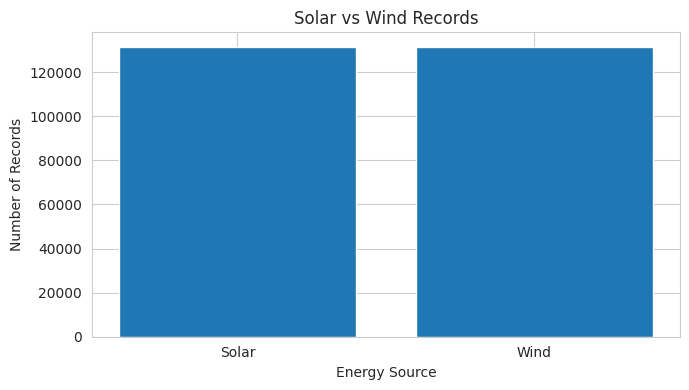

In [ ]:
# ============================================
# BLOCK 3: ENERGY SOURCE DISTRIBUTION
# ============================================

energy_source = df["energy_source"].value_counts()

print("========== ENERGY SOURCE DISTRIBUTION ==========")
for source, count in energy_source.items():
    print(f"{source} Records : {count}")

print(f"\nNumber of Energy Sources : {df['energy_source'].nunique()}")
print(f"Average Energy Output   : {df['energy_output_kwh'].mean():,.2f} kWh")

plt.figure(figsize=(7, 4))

plt.bar(energy_source.index.astype(str), energy_source.values)

plt.title("Solar vs Wind Records")
plt.xlabel("Energy Source")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

========== NUMERICAL FEATURES ==========
Number of numerical features: 22


,count,mean,std,min,25%,50%,75%,max
plant_capacity_mw,263040.0,65.50,29.36,25.00,50.00,50.00,100.00,100.00
panel_efficiency,131520.0,0.21,0.01,0.18,0.20,0.21,0.21,0.22
turbine_hub_height_m,131520.0,112.00,24.00,80.00,100.00,100.00,140.00,140.00
hour,263040.0,11.50,6.92,0.00,5.75,11.50,17.25,23.00
day,263040.0,15.73,8.80,1.00,8.00,16.00,23.00,31.00
month,263040.0,6.52,3.45,1.00,4.00,7.00,10.00,12.00
year,263040.0,2023.00,0.82,2022.00,2022.00,2023.00,2024.00,2024.00
day_of_week,263040.0,3.00,2.00,0.00,1.00,3.00,5.00,6.00
day_of_year,263040.0,183.17,105.46,1.00,92.00,183.00,274.25,366.00
is_weekend,263040.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00


/tmp/ipykernel_503/3040606803.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


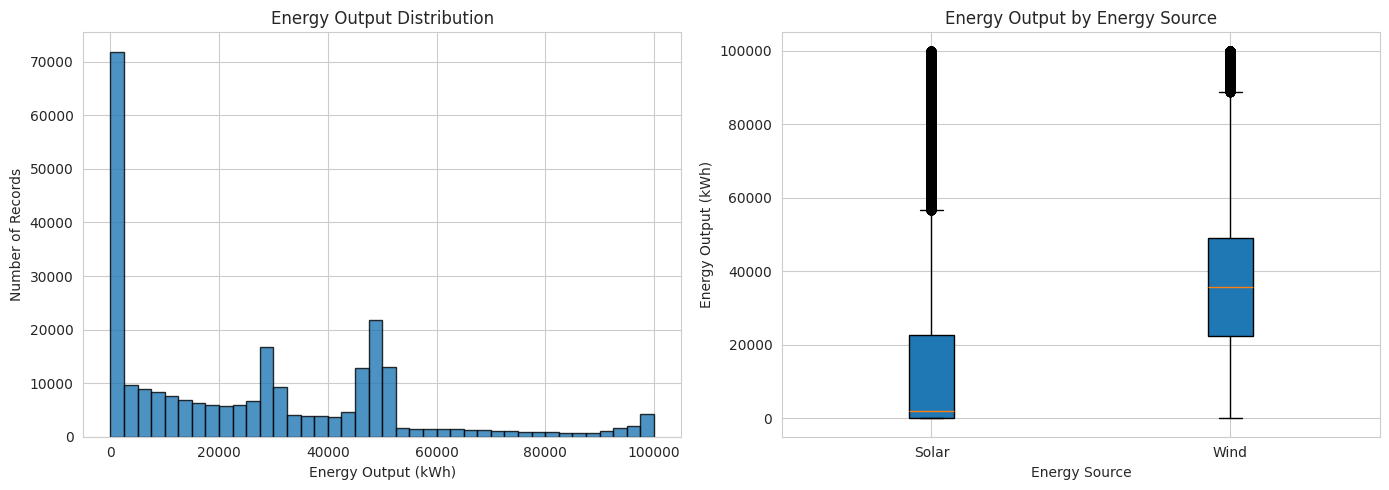

In [ ]:
# ============================================
# BLOCK 4: NUMERICAL ANALYSIS
# ============================================

print("========== NUMERICAL FEATURES ==========")

num_cols = df.select_dtypes(include=np.number).columns

print("Number of numerical features:", len(num_cols))

display(df[num_cols].describe().T.round(2))

# Energy output distribution and output by energy source
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["energy_output_kwh"],
    bins=40,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Energy Output Distribution")
axes[0].set_xlabel("Energy Output (kWh)")
axes[0].set_ylabel("Number of Records")

sources = list(df["energy_source"].dropna().unique())
box_data = [
    df.loc[df["energy_source"] == source, "energy_output_kwh"].dropna()
    for source in sources
]

axes[1].boxplot(
    box_data,
    labels=sources,
    patch_artist=True
)

axes[1].set_title("Energy Output by Energy Source")
axes[1].set_xlabel("Energy Source")
axes[1].set_ylabel("Energy Output (kWh)")

plt.tight_layout()
plt.show()

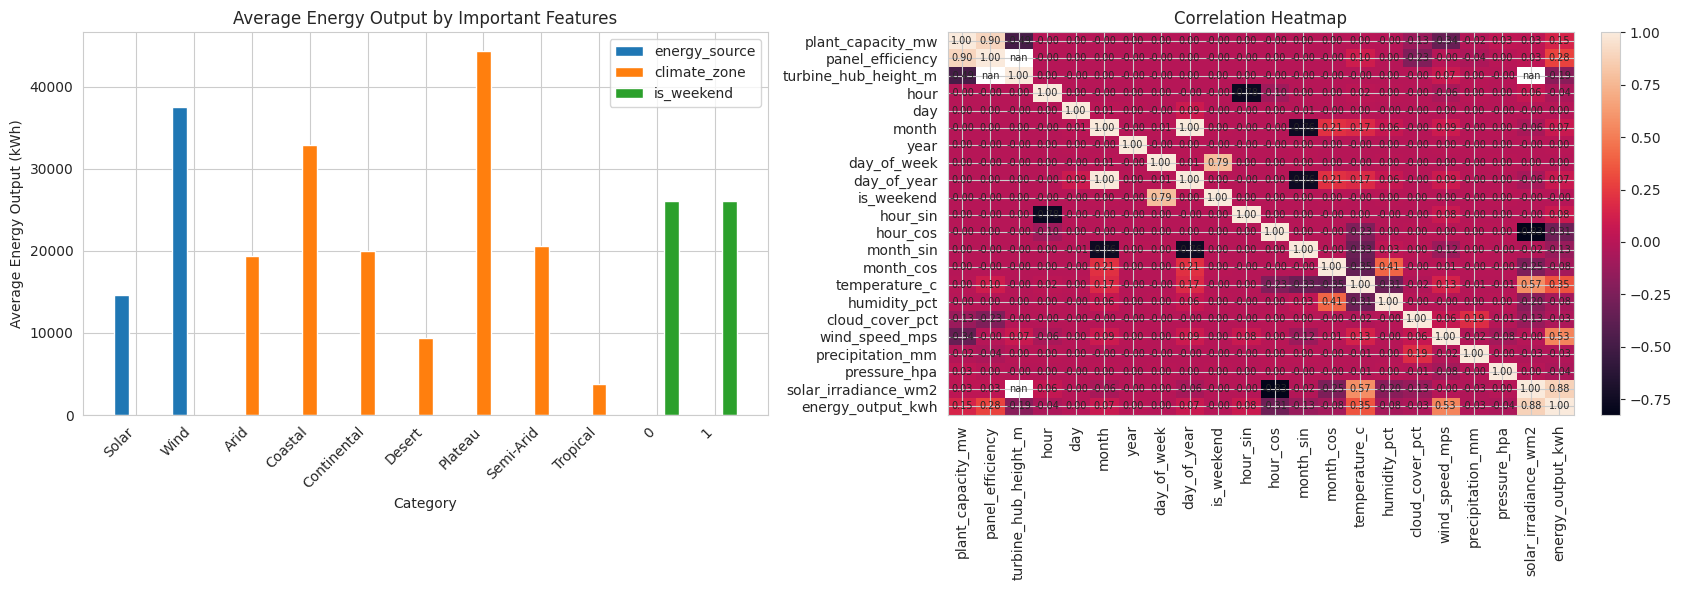

In [ ]:
# ============================================
# BLOCK 5: ENERGY FACTORS & CORRELATION
# ============================================

features = [
    "energy_source",
    "climate_zone",
    "is_weekend"
]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# --------------------------------------------
# Average energy output by important features
# --------------------------------------------

energy_rates = []

for feature in features:

    temp = df.groupby(feature)["energy_output_kwh"].mean()
    temp = temp.reset_index()

    temp["Feature"] = feature
    temp["Category"] = temp[feature].astype(str)
    temp = temp[["Feature", "Category", "energy_output_kwh"]]

    energy_rates.append(temp)

energy_rates = pd.concat(energy_rates, ignore_index=True)

# Matplotlib grouped bars, keeping the same idea as the reference
categories = list(energy_rates["Category"].unique())
feature_names = energy_rates["Feature"].unique().tolist()

x = np.arange(len(categories))
width = 0.25

for i, feature in enumerate(feature_names):
    temp = energy_rates[energy_rates["Feature"] == feature]
    values = []
    for cat in categories:
        match = temp.loc[temp["Category"] == cat, "energy_output_kwh"]
        values.append(match.iloc[0] if len(match) else np.nan)

    offset = (i - (len(feature_names)-1)/2) * width
    axes[0].bar(x + offset, values, width, label=feature)

axes[0].set_title("Average Energy Output by Important Features")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Average Energy Output (kWh)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=45, ha="right")
axes[0].legend()

# --------------------------------------------
# Correlation heatmap
# --------------------------------------------

corr = df.select_dtypes(include=np.number).corr()

im = axes[1].imshow(corr, aspect="auto")
axes[1].set_title("Correlation Heatmap")

axes[1].set_xticks(np.arange(len(corr.columns)))
axes[1].set_yticks(np.arange(len(corr.index)))
axes[1].set_xticklabels(corr.columns, rotation=90)
axes[1].set_yticklabels(corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        axes[1].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()